# Imports

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import correlate
from hapi import *
from pylab import plot
# from bin_spec import bin_spectrum

%matplotlib widget

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

# Configuration

In [4]:
DATA_DIR = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data"
hapi_data_dir = "HAPI_DB"
atmospheric_profile_path = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data/external/atmosphere_profile.csv"

db_begin(hapi_data_dir)

Using HAPI_DB

CH4
                     Lines parsed: 2946
CH4_iso2
                     Lines parsed: 11300
H2O_iso3
                     Lines parsed: 763
N2_iso1
                     Lines parsed: 24
H2O_iso1
                     Lines parsed: 528
CH4_iso1
                     Lines parsed: 4093
H2O_main
                     Lines parsed: 1123
CH4_iso3
                     Lines parsed: 962
N2O_iso1
                     Lines parsed: 5027
H2O
                     Lines parsed: 15602
H2O_iso2
                     Lines parsed: 983


# User parameters

In [5]:
wl_min = 7.8
wl_max = 8.2
native_dwn = 0.001     # cm^-1, native HITRAN-resolution sampling (HAPI side)

wn_min = 1e4/wl_max
wn_max = 1e4/wl_min


In [6]:
df_atmospheric_profile_table = pd.read_csv(atmospheric_profile_path)

In [6]:
tableList()

dict_keys(['sampletab', 'CH4', 'CH4_iso2', 'H2O_iso3', 'N2_iso1', 'H2O_iso1', 'CH4_iso1', 'H2O_main', 'CH4_iso3', 'N2O_iso1', 'H2O', 'H2O_iso2'])

# Helper Functions

In [18]:
kB = 1.380649e-23  # Boltzmann constant, J/K

def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def compute_absorption_coefficient(molecule, isotope, dwn, altitude):
    """Compute absorption coefficient (cm^-1) for pure gas at layer conditions."""
    print(f"Computing coef for {molecule} iso{isotope} at alt {altitude}")
    M, __ = get_molecule_id(molecule)
    
    table_name = f"{molecule}_iso{isotope}"
    
    p_atm = df_atmospheric_profile_table["PRES_mb"].iloc[altitude] / 1013.25
    vmr = df_atmospheric_profile_table[f"{molecule}_ppmv"].iloc[altitude] / 1e6

    wn_grid, coef = absorptionCoefficient_Voigt(
        Components=[(M, isotope, vmr)],  # pure gas -> scale by vmr later
        Diluent={'self': vmr, 'air': 1.0 - vmr},
        SourceTables=table_name,
        WavenumberRange=(wn_min, wn_max),
        WavenumberStep=dwn,
        Environment={
            'T': df_atmospheric_profile_table["TEMP_K"].iloc[altitude], 
            'p': p_atm # Convert from mb to atmospheres
        },
        HITRAN_units=False  # Get absorption coefficient in cm^-1
    )

    
    
    return wn_grid, coef

def compute_transmission(molecules_isotopes, dwn, altitudes):
    alt_df = df_atmospheric_profile_table.iloc[altitudes].reset_index(drop=True)
    print("Available columns:", list(alt_df.columns))
    
    alt_km = alt_df["ALT_km"].values
    dz_km = np.diff(alt_km, append=alt_km[-1] + np.median(np.diff(alt_km)))
    dz_cm = dz_km * 1e5
    
    #temporary debug:
    # dz_cm *= 0.1

    total_tau = None
    wn_grid_ref = None
    
    for mol, iso in molecules_isotopes:
        col_name = f"{mol}_ppmv"   # <--- exact match to CSV
        print(f"Looking for column: {col_name}")
        if col_name not in alt_df.columns:
            print("ERROR: Column not found! Using available VMR-like columns:", [c for c in alt_df.columns if 'ppm' in c.lower() or 'vmr' in c.lower()])
            continue
            
        print(f"→ Processing {mol} iso{iso}")
        for i, row in alt_df.iterrows():
            wn_grid, coef_pure = compute_absorption_coefficient(mol, iso, dwn, i)
            if wn_grid_ref is None:
                wn_grid_ref = wn_grid.copy()
            
            ppmv = float(row[col_name])
            vmr = ppmv * 1e-6
            
            delta_tau = coef_pure * vmr * dz_cm[i]
            
            if total_tau is None:
                total_tau = np.zeros_like(coef_pure)
            total_tau += delta_tau
            
            if i % 15 == 0:
                print(f"  Layer {alt_km[i]:5.1f} km | ppmv={ppmv:8.2f} | vmr={vmr:.2e} | max_delta_tau={np.max(delta_tau):.2e} | cum_max_tau={np.max(total_tau):.2e}")
    
    if total_tau is None:
        raise ValueError("No tau accumulated")
    
    print(f"\nFINAL: max_tau = {np.max(total_tau):.2f}, mean_tau = {np.mean(total_tau):.2f}")
    transmission = np.exp(-total_tau)
    print(f"Transmission range: {transmission.min():.6f} to {transmission.max():.6f}")
    
    wavelengths_um = 1e4 / wn_grid_ref
    return wavelengths_um, transmission, wn_grid_ref

# Test - Earth T-P Profile

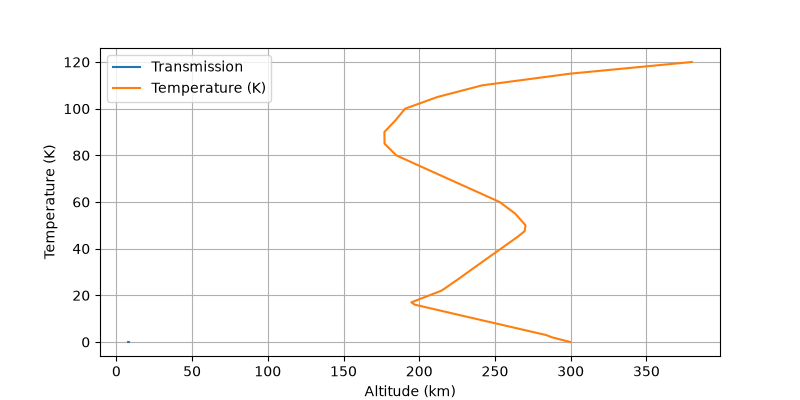

In [49]:
plt.Figure(figsize=(8, 4))
plt.plot(df_atmospheric_profile_table["TEMP_K"], df_atmospheric_profile_table["ALT_km"], label="Temperature (K)")
plt.xlabel("Altitude (km)")
plt.ylabel("Temperature (K)")
plt.grid(True)
plt.legend()
plt.show()

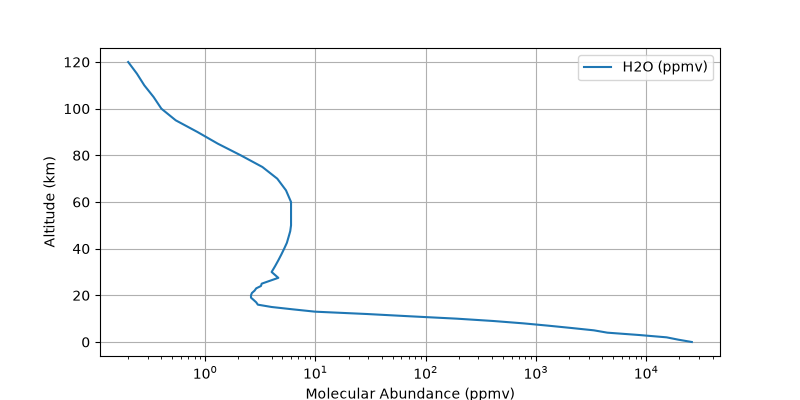

In [9]:
# Plotting molecular abundance profiles 

plt.figure(figsize=(8, 4))
plt.plot(df_atmospheric_profile_table["H2O_ppmv"], df_atmospheric_profile_table["ALT_km"], label="H2O (ppmv)")
# plt.plot( df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["CH4_ppmv"], label="CH4 (ppmv)")
# plt.plot(df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["O3_ppmv"], label="O3 (ppmv)")
# plt.plot(df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["N2O_ppmv"], label="N2O (ppmv)")
plt.xscale("log")
plt.xlabel("Molecular Abundance (ppmv)")
plt.ylabel("Altitude (km)")
plt.grid(True)
plt.legend()
plt.show()

# Test Reflectivity Spectra

In [19]:
# Example
mols = [('H2O', 1)]  # adjust isotopes
alts = range(len(df_atmospheric_profile_table))  # or subset
wl, trans, wn = compute_transmission(mols, dwn=0.01, altitudes=alts)

Available columns: ['ALT_km', 'PRES_mb', 'TEMP_K', 'DENSITY_cm3', 'H2O_ppmv', 'O3_ppmv', 'N2O_ppmv', 'CO_ppmv', 'CH4_ppmv']
Looking for column: H2O_ppmv
→ Processing H2O iso1
Computing coef for H2O iso1 at alt 0
{'self': np.float64(0.0259), 'air': np.float64(0.9741)}
0.260416 seconds elapsed for abscoef; nlines = 528
  Layer   0.0 km | ppmv=25900.00 | vmr=2.59e-02 | max_delta_tau=1.12e+01 | cum_max_tau=1.12e+01
Computing coef for H2O iso1 at alt 1
{'self': np.float64(0.0195), 'air': np.float64(0.9805)}
0.247847 seconds elapsed for abscoef; nlines = 528
Computing coef for H2O iso1 at alt 2
{'self': np.float64(0.0153), 'air': np.float64(0.9847)}
0.251508 seconds elapsed for abscoef; nlines = 528
Computing coef for H2O iso1 at alt 3
{'self': np.float64(0.0086), 'air': np.float64(0.9914)}
0.303607 seconds elapsed for abscoef; nlines = 528
Computing coef for H2O iso1 at alt 4
{'self': np.float64(0.00444), 'air': np.float64(0.99556)}
0.256136 seconds elapsed for abscoef; nlines = 528
Computi

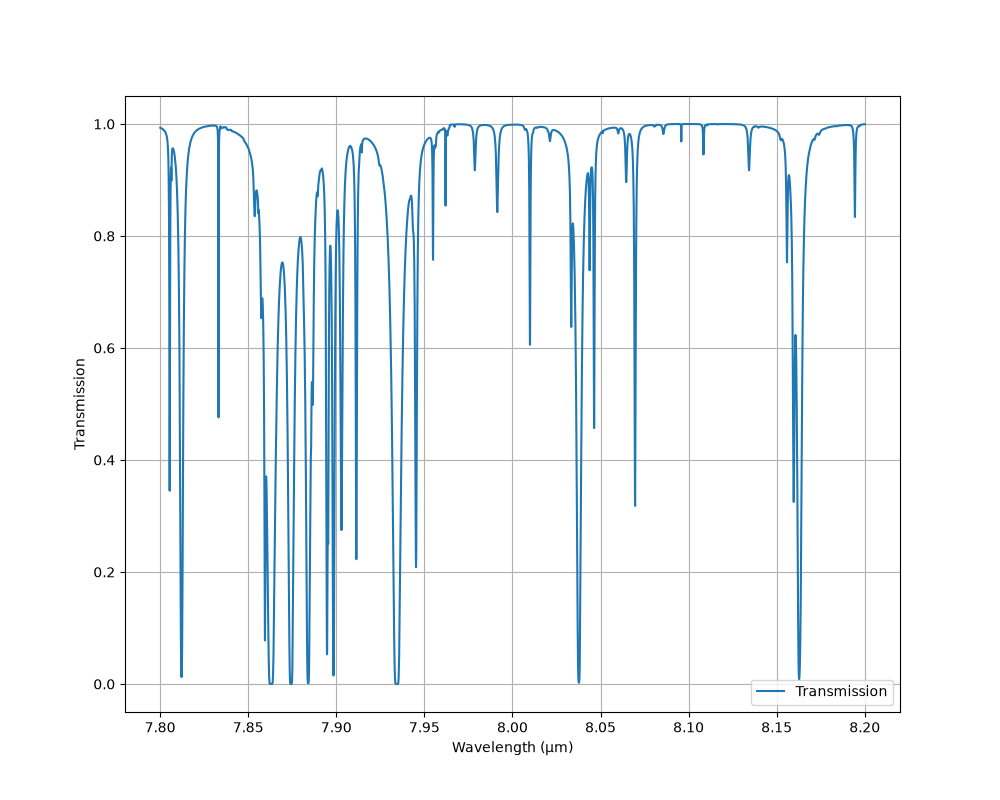

In [20]:
plt.cla()
plt.figure(figsize=(10, 8))
plt.plot(wl, trans, label="Transmission")
plt.xlabel("Wavelength (μm)")
plt.ylabel("Transmission")
# plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()